In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Paths

In [ ]:
dataset = 'data/dynamic_gestures/dynamic_gesturesV3.csv'
model_save_path = 'model/dynamic_gestures/dynamic_gestures_modelV3.h5'

# Number of classes

In [3]:
NUM_CLASSES = 5

# Dataset reading

In [4]:
TIME_STEPS = 16
DIMENSION = 2

In [5]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (TIME_STEPS * DIMENSION) + 1)))

In [6]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [8]:
use_lstm = True
model = None

if use_lstm:
    model = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(TIME_STEPS * DIMENSION, )),
        tf.keras.layers.Reshape((TIME_STEPS, DIMENSION), input_shape=(TIME_STEPS * DIMENSION, )), 
        tf.keras.layers.Dropout(0.2),
        # CAMBIO RECOMENDADO: Subir de 16 a 64 unidades LSTM
        tf.keras.layers.LSTM(64, input_shape=[TIME_STEPS, DIMENSION]), 
        tf.keras.layers.Dropout(0.5),
        # CAMBIO RECOMENDADO: Subir de 10 a 32 en la capa Dense
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
else:
    model = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(TIME_STEPS * DIMENSION, )),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(24, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])

c:\Users\Yefri Estiven Vera\Documents\GitHub\TESIS_GR\gestos\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
c:\Users\Yefri Estiven Vera\Documents\GitHub\TESIS_GR\gestos\lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Yefri Estiven Vera\Documents\GitHub\TESIS_GR\gestos\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 16, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,397 (75.77 KB)

 Trainable params: 19,397 (75.77 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training 

In [12]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3964 - loss: 1.5810
Epoch 1: saving model to model/dynamic_gestures/dynamic_gestures_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4759 - loss: 1.5445 - val_accuracy: 0.5895 - val_loss: 1.3971
Epoch 2/1000
38/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6159 - loss: 1.2706
Epoch 2: saving model to model/dynamic_gestures/dynamic_gestures_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6765 - loss: 1.1203 - val_accuracy: 0.7583 - val_loss: 0.8763
Epoch 3/1000
38/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7688 - loss: 0.8335
Epoch 3: saving model to model/dynamic_gestures/dynamic_gestures_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7619 - loss: 0.8161 - val_accuracy: 0.7626 - val_loss: 0.7190
Epoch 4/1000
38/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7632 - loss: 0.7507
Epoch 4: saving model to model/dynamic_gestures/dynamic_gestures_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7669 - loss: 0.7374 - val_accuracy: 0.7749 - val_loss: 0.6656
Epoch 5/1000
40/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7745 - loss: 0.6942
Epoch 5: saving model to model/dynamic_gestures/dynamic_gestures_model.h5


...

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9109 - loss: 0.2654 - val_accuracy: 0.9110 - val_loss: 0.2661
Epoch 114/1000
42/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9164 - loss: 0.2666
Epoch 114: saving model to model/dynamic_gestures/dynamic_gestures_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9151 - loss: 0.2715 - val_accuracy: 0.9073 - val_loss: 0.2778
Epoch 115/1000
40/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9161 - loss: 0.2659
Epoch 115: saving model to model/dynamic_gestures/dynamic_gestures_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9162 - loss: 0.2611 - val_accuracy: 0.9051 - val_loss: 0.2781
Epoch 116/1000
41/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9195 - loss: 0.2417
Epoch 116: saving model to model/dynamic_gestures/dynamic_gestures_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9126 - loss: 0.2561 - val_accuracy: 0.9089 - val_loss: 0.2639
Epoch 117/1000
36/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9087 - loss: 0.2619
Epoch 117: saving model to model/dynamic_gestures/dynamic_gestures_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9089 - loss: 0.2622 - val_accuracy: 0.9051 - val_loss: 0.2783
Epoch 117: early stopping


In [13]:
model = tf.keras.models.load_model(model_save_path)

In [14]:
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
[1.7086683e-12 9.9876046e-01 1.1610970e-03 7.0672822e-06 7.1397109e-05]
1


# Confusion matrix

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


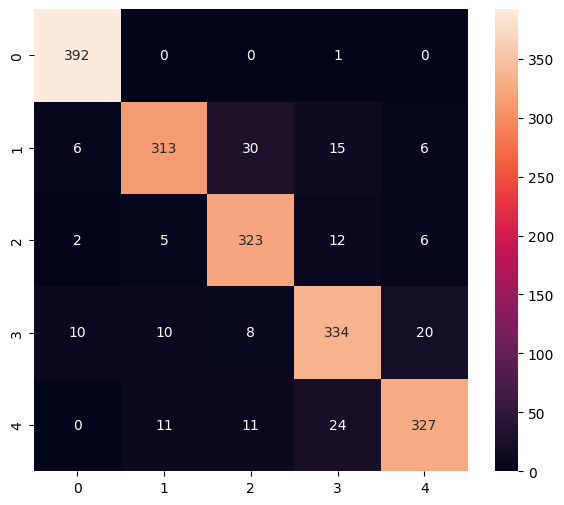

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       393
           1       0.92      0.85      0.88       370
           2       0.87      0.93      0.90       348
           3       0.87      0.87      0.87       382
           4       0.91      0.88      0.89       373

    accuracy                           0.91      1866
   macro avg       0.90      0.90      0.90      1866
weighted avg       0.91      0.91      0.90      1866



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite


In [16]:
model.save(model_save_path, include_optimizer=False)
model = tf.keras.models.load_model(model_save_path)

In [ ]:
tflite_save_path = 'model/dynamic_gestures/dynamic_gestures_modelV3.tflite'

In [18]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# ADD THIS SECTION
converter.target_spec.supported_ops = [
  tf.lite.OpsSet.TFLITE_BUILTINS, # Enable standard TFLite ops
  tf.lite.OpsSet.SELECT_TF_OPS    # Enable Flex ops (fixes the TensorList error)
]
# END ADDITION

tflite_quantized_model = converter.convert()

with open(tflite_save_path, 'wb') as f:
    f.write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\YEFRIE~1\AppData\Local\Temp\tmpghv9807c\assets


INFO:tensorflow:Assets written to: C:\Users\YEFRIE~1\AppData\Local\Temp\tmpghv9807c\assets


Saved artifact at 'C:\Users\YEFRIE~1\AppData\Local\Temp\tmpghv9807c'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2052052283664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2052052515680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2052052516384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2052052609408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2052052610112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2052052613632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2052052733440: TensorSpec(shape=(), dtype=tf.resource, name=None)


# Inference test

In [19]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

c:\Users\Yefri Estiven Vera\Documents\GitHub\TESIS_GR\gestos\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [20]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print(input_details)

[{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([ 1, 32]), 'shape_signature': array([-1, 32]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [21]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [22]:
%%time
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 5 ms


In [23]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.6877955e-12 9.9879861e-01 1.1253813e-03 7.0910132e-06 6.8806723e-05]
1
